In [1]:
import duckdb

In [30]:
import pandas as pd

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Connect to an in-memory DuckDB instance
con = duckdb.connect(database=':memory:')

In [31]:
# Force Pandas to show all columns so nothing gets hidden
pd.set_option('display.max_columns', None)

## schema

In [33]:
print("--- DATABASE SCHEMA ---")

#reading parquet files
schema_query = "DESCRIBE SELECT * FROM '../data/*.parquet'"
schema_df = con.execute(schema_query).df()
print(schema_df[['column_name', 'column_type']])

print("\n" + "="*50 + "\n")

# view data
print("--- FIRST 5 ROWS ---")
data_query = "SELECT * FROM '../data/*.parquet' LIMIT 5"
data_df = con.execute(data_query).df()
display(data_df)

--- DATABASE SCHEMA ---
              column_name column_type
0                VendorID     INTEGER
1    tpep_pickup_datetime   TIMESTAMP
2   tpep_dropoff_datetime   TIMESTAMP
3         passenger_count      BIGINT
4           trip_distance      DOUBLE
5              RatecodeID      BIGINT
6      store_and_fwd_flag     VARCHAR
7            PULocationID     INTEGER
8            DOLocationID     INTEGER
9            payment_type      BIGINT
10            fare_amount      DOUBLE
11                  extra      DOUBLE
12                mta_tax      DOUBLE
13             tip_amount      DOUBLE
14           tolls_amount      DOUBLE
15  improvement_surcharge      DOUBLE
16           total_amount      DOUBLE
17   congestion_surcharge      DOUBLE
18            Airport_fee      DOUBLE
19     cbd_congestion_fee      DOUBLE


--- FIRST 5 ROWS ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.90,1,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.40,1,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,1,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,1,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


# The Time-Series Aggregation Engine.

In [36]:
query = """
WITH time_binned_data AS (
    SELECT 
        PULocationID AS location_id,
        -- Bin the pickup times into 15-minute intervals
        time_bucket(INTERVAL '15 minutes', tpep_pickup_datetime) AS time_interval,
        COUNT(*) AS trip_demand,
        AVG(fare_amount) AS avg_base_fare
    FROM '../data/*.parquet'
    -- Filter out dirty data (NYC TLC data often has random years mixed in)
    WHERE tpep_pickup_datetime >= '2026-01-01' AND tpep_pickup_datetime < '2026-03-01'
    GROUP BY 1, 2
),
rolling_metrics AS (
    SELECT 
        location_id,
        time_interval,
        trip_demand,
        avg_base_fare,
        -- Calculate the rolling average demand for this specific location over the last 2 hours (8 intervals)
        AVG(trip_demand) OVER (
            PARTITION BY location_id 
            ORDER BY time_interval 
            ROWS BETWEEN 8 PRECEDING AND 1 PRECEDING
        ) AS rolling_avg_demand
    FROM time_binned_data
)
SELECT 
    location_id,
    time_interval,
    trip_demand,
    rolling_avg_demand,
    avg_base_fare,
    -- Calculate how much current demand is spiking compared to the recent historical baseline
    CASE 
        WHEN rolling_avg_demand > 0 THEN (trip_demand * 1.0) / rolling_avg_demand 
        ELSE 1.0 
    END AS demand_spike_ratio
FROM rolling_metrics
WHERE time_interval IS NOT NULL
ORDER BY location_id, time_interval
"""

In [37]:
print("Executing 30M+ row aggregation...")
# Execute and load into a Pandas DataFrame for the next ML phase
df_aggregated = con.execute(query).df()

print(f"Aggregation complete. Output shape: {df_aggregated.shape}")
display(df_aggregated.head(10))

Executing 30M+ row aggregation...
Aggregation complete. Output shape: (635273, 6)


,location_id,time_interval,trip_demand,rolling_avg_demand,avg_base_fare,demand_spike_ratio
0,1,2026-01-01 02:30:00,1,NaN,130.000000,1.000000
1,1,2026-01-01 04:00:00,1,1.000000,40.000000,1.000000
2,1,2026-01-01 04:45:00,2,1.000000,42.500000,2.000000
3,1,2026-01-01 05:15:00,2,1.333333,23.000000,1.500000
4,1,2026-01-01 05:30:00,3,1.500000,18.333333,2.000000
5,1,2026-01-01 06:15:00,1,1.800000,75.000000,0.555556
6,1,2026-01-01 06:30:00,1,1.666667,79.000000,0.600000
7,1,2026-01-01 07:00:00,1,1.571429,120.000000,0.636364
8,1,2026-01-01 07:30:00,1,1.500000,25.000000,0.666667
9,1,2026-01-01 08:00:00,1,1.500000,128.000000,0.666667


# visualizations

In [39]:
# --- 1. THE SURGE PRICING ALGORITHM ---
def calculate_surge(spike_ratio):
    """
    Maps the statistical demand spike to a business pricing multiplier.
    Includes a hard cap to prevent long-term user churn.
    """
    if spike_ratio < 1.2:
        return 1.0  # Normal demand, base fare
    elif spike_ratio < 1.5:
        return 1.2  # Slight imbalance
    elif spike_ratio < 2.0:
        return 1.5  # Heavy demand
    elif spike_ratio < 3.0:
        return 2.0  # Severe imbalance (e.g., concert ending)
    else:
        return 2.5  # Hard cap. Above this, LTV (Lifetime Value) drops due to churn.

# Apply the algorithm to our dataset
df_aggregated['surge_multiplier'] = df_aggregated['demand_spike_ratio'].apply(calculate_surge)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3856\328717646.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_aggregated, x='surge_multiplier', palette='rocket_r')


Saved: ../images/surge_distribution.png


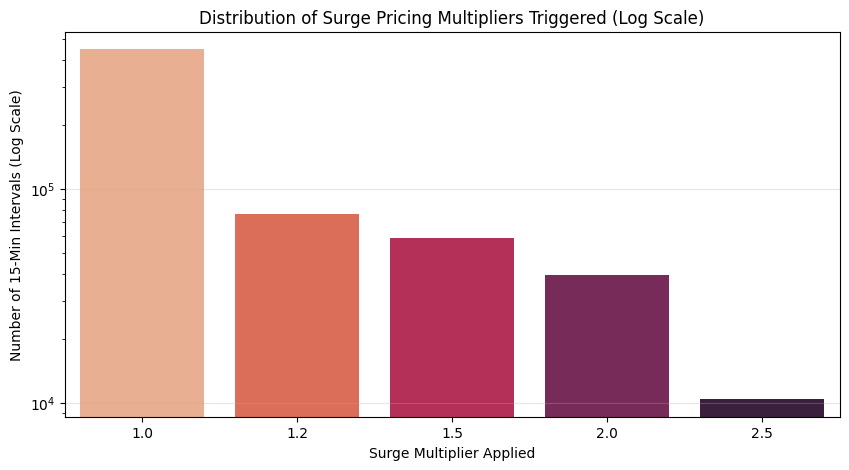

In [45]:
# --- 2. VISUALIZATION 1: The Multiplier Distribution ---
plt.figure(figsize=(10, 5))
# Using a log scale because 1.0x will naturally dominate the dataset
ax = sns.countplot(data=df_aggregated, x='surge_multiplier', palette='rocket_r')
plt.title('Distribution of Surge Pricing Multipliers Triggered (Log Scale)')
plt.xlabel('Surge Multiplier Applied')
plt.ylabel('Number of 15-Min Intervals (Log Scale)')
plt.yscale('log') 
plt.grid(axis='y', alpha=0.3)

plt.savefig('../images/surge_distribution.png', dpi=300, bbox_inches='tight')
print("Saved: ../images/surge_distribution.png")
plt.show()

Saved: ../images/surge_timeline.png


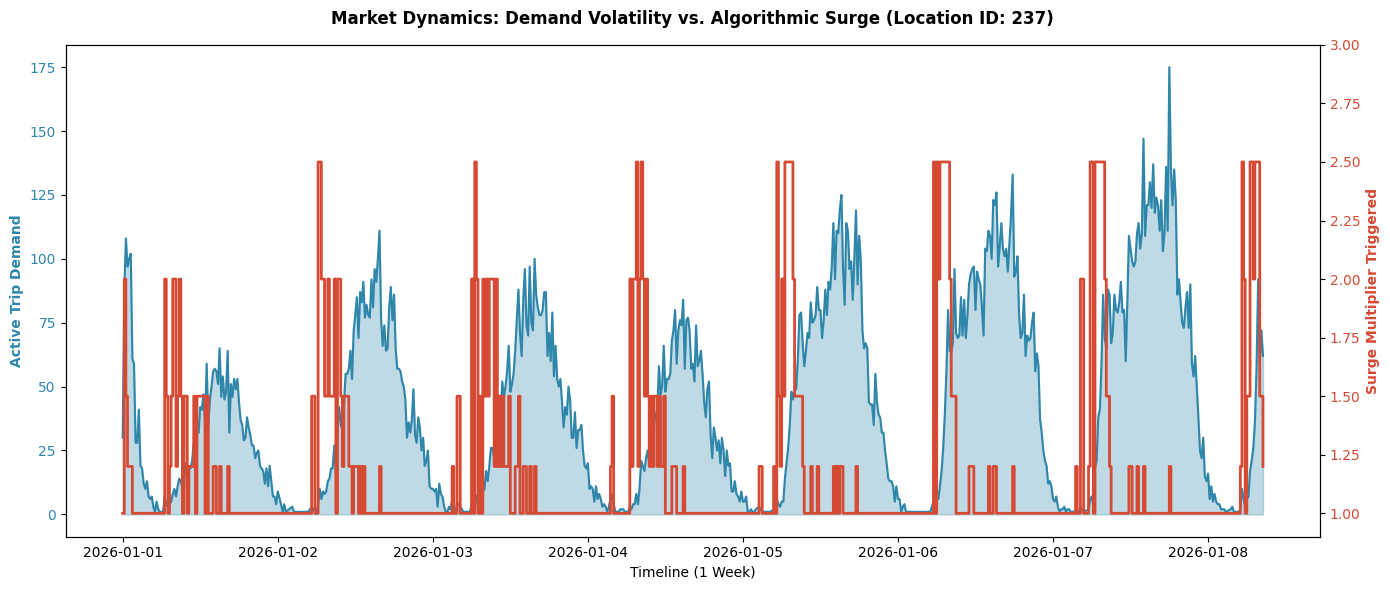

In [44]:
# --- 3. VISUALIZATION 2: The Busiest Neighborhood Teardown ---
# Find the single busiest location in the entire dataset automatically
busiest_loc = df_aggregated.groupby('location_id')['trip_demand'].sum().idxmax()
df_busiest = df_aggregated[df_aggregated['location_id'] == busiest_loc].sort_values('time_interval')

# Slice just the first 7 days of data for a clean chart (4 intervals/hr * 24 hrs * 7 days = 672)
df_week = df_busiest.head(672)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot the raw demand as a smooth area
color1 = '#2E86AB'
ax1.set_xlabel('Timeline (1 Week)')
ax1.set_ylabel('Active Trip Demand', color=color1, fontweight='bold')
ax1.fill_between(df_week['time_interval'], df_week['trip_demand'], color=color1, alpha=0.3)
ax1.plot(df_week['time_interval'], df_week['trip_demand'], color=color1, linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color1)

# Plot the Surge Multiplier stepping up and down on a secondary axis
ax2 = ax1.twinx()  
color2 = '#D64933'
ax2.set_ylabel('Surge Multiplier Triggered', color=color2, fontweight='bold')
ax2.step(df_week['time_interval'], df_week['surge_multiplier'], color=color2, where='post', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0.9, 3.0)

plt.title(f'Market Dynamics: Demand Volatility vs. Algorithmic Surge (Location ID: {busiest_loc})', pad=15, fontweight='bold')
fig.tight_layout()

plt.savefig('../images/surge_timeline.png', dpi=300, bbox_inches='tight')
print("Saved: ../images/surge_timeline.png")
plt.show()

# Elasticity and GMV

In [46]:
# --- THE ECONOMIC MODEL: Price Elasticity ---
# If price increases by 100% (2.0x surge), and elasticity is -0.4, demand drops by 40%.
ELASTICITY_COEFFICIENT = -0.4

In [47]:
def calculate_surged_demand(row):
    """Calculates how many trips we actually fulfill after the surge price scares some users away."""
    price_increase_pct = row['surge_multiplier'] - 1.0
    demand_drop_pct = price_increase_pct * ELASTICITY_COEFFICIENT
    
    # New demand cannot fall below 0
    retained_demand_pct = max(0, 1.0 + demand_drop_pct)
    return row['trip_demand'] * retained_demand_pct

In [49]:
# --- RUNNING THE SIMULATION ---
print("Running Revenue Simulation with Price Elasticity...")

# 1. Baseline GMV (What NYC Taxis actually made with flat rates)
df_aggregated['baseline_gmv'] = df_aggregated['trip_demand'] * df_aggregated['avg_base_fare']

# 2. Simulated Surged Demand
df_aggregated['simulated_surge_demand'] = df_aggregated.apply(calculate_surged_demand, axis=1)

# 3. Simulated Surged GMV (New Demand * New Price)
df_aggregated['simulated_surge_gmv'] = df_aggregated['simulated_surge_demand'] * (df_aggregated['avg_base_fare'] * df_aggregated['surge_multiplier'])

# --- CALCULATING THE LIFT ---
total_baseline_gmv = df_aggregated['baseline_gmv'].sum()
total_surged_gmv = df_aggregated['simulated_surge_gmv'].sum()

gmv_lift_dollars = total_surged_gmv - total_baseline_gmv
gmv_lift_pct = (gmv_lift_dollars / total_baseline_gmv) * 100

total_baseline_trips = df_aggregated['trip_demand'].sum()
total_surged_trips = df_aggregated['simulated_surge_demand'].sum()
trip_loss_pct = ((total_baseline_trips - total_surged_trips) / total_baseline_trips) * 100

print("\n" + "="*40)
print("🎯 SURGE ALGORITHM PERFORMANCE REPORT")
print("="*40)
print(f"Total Baseline GMV:      ${total_baseline_gmv:,.2f}")
print(f"Total Surged GMV:        ${total_surged_gmv:,.2f}")
print(f"Net Revenue Lift:        +${gmv_lift_dollars:,.2f} (+{gmv_lift_pct:.2f}%)")
print("-" * 40)
print(f"Baseline Trips Fulfilled: {total_baseline_trips:,.0f}")
print(f"Surged Trips Fulfilled:   {total_surged_trips:,.0f}")
print(f"Strategic Trip Loss:      {trip_loss_pct:.2f}% (Priced out due to elasticity)")
print("="*40)

Running Revenue Simulation with Price Elasticity...

🎯 SURGE ALGORITHM PERFORMANCE REPORT
Total Baseline GMV:      $151,089,230.58
Total Surged GMV:        $159,407,239.06
Net Revenue Lift:        +$8,318,008.48 (+5.51%)
----------------------------------------
Baseline Trips Fulfilled: 7,124,745
Surged Trips Fulfilled:   6,644,222
Strategic Trip Loss:      6.74% (Priced out due to elasticity)
